In [1]:
pip install torch torchvision

In [2]:
import torch
import torchvision
import torchvision.models.detection as models
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [3]:
import os
import numpy as np
import pandas as pd
import torchvision
import ast
import re
import cv2
from sklearn.metrics import auc
from PIL import Image, ImageDraw
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.ops import box_iou
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision.transforms as transforms
from torchvision.models.detection import FasterRCNN

In [4]:
# Hàm tạo mô hình Faster R-CNN
def get_model(num_classes):
    # Sử dụng Faster R-CNN với backbone ResNet50
    # model = models.fasterrcnn_resnet50_fpn(weights=models.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Thay đổi đầu ra (head) để phù hợp với số lớp của bạn
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

    return model

# Khởi tạo mô hình
num_classes = 7
model = get_model(num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:04<00:00, 41.2MB/s]


In [ ]:
checkpoint = torch.load("fasterrcnn_resnet50_fpn_epoch_5.pth", map_location='cpu')

In [ ]:
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

<ipython-input-6-cbd326ef9164>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/fasterrcnn_resnet50_fpn_epoch_3.pth",map_location=

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [7]:
label_mapping = {
    'DNoHelmet': 1,
    'DHelmet': 2,
    'DHelmetPHelmet': 3,
    'DHelmetPNoHelmet': 4,
    'DNoHelmetPHelmet': 5,
    'DNoHelmetPNoHelmet': 6
}

In [8]:
label_mapping_2 = {
    1: 'DNoHelmet',
    2: 'DHelmet',
    3: 'DHelmetPHelmet',
    4: 'DHelmetPNoHelmet',
    5: 'DNoHelmetPHelmet',
    6: 'DNoHelmetPNoHelmet'
}

In [9]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Dự đoán ảnh

In [10]:
transform = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor()
])

In [15]:
image_path = r"/content/IMG_0312.JPG"
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

with torch.no_grad():
    predictions = model(image_tensor)

In [17]:
predicted_boxes = predictions[0]['boxes'].cpu().numpy()
predicted_labels = predictions[0]['labels'].cpu().numpy()
predicted_scores = predictions[0]['scores'].cpu().numpy()

threshold = 0.5
filtered_indices = predicted_scores > threshold

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i]}, Label: {filtered_labels[i]}, Score: {filtered_scores[i]}")

Box: [314.77704 290.81445 352.89078 356.83997], Label: 1, Score: 0.7704404592514038


In [ ]:
predicted_boxes = predictions[0]['boxes'].cpu()
predicted_labels = predictions[0]['labels'].cpu()
predicted_scores = predictions[0]['scores'].cpu()

# Thiết lập ngưỡng confidence
threshold = 0.5
filtered_indices = predicted_scores > threshold

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

# Áp dụng NMS
iou_threshold = 0.5  # Ngưỡng IoU để loại bỏ các box dư thừa
nms_indices = nms(filtered_boxes, filtered_scores, iou_threshold)

# Lấy các box, label, score sau khi áp dụng NMS
filtered_boxes = filtered_boxes[nms_indices]
filtered_labels = filtered_labels[nms_indices]
filtered_scores = filtered_scores[nms_indices]

filtered_labels = filtered_labels.numpy()

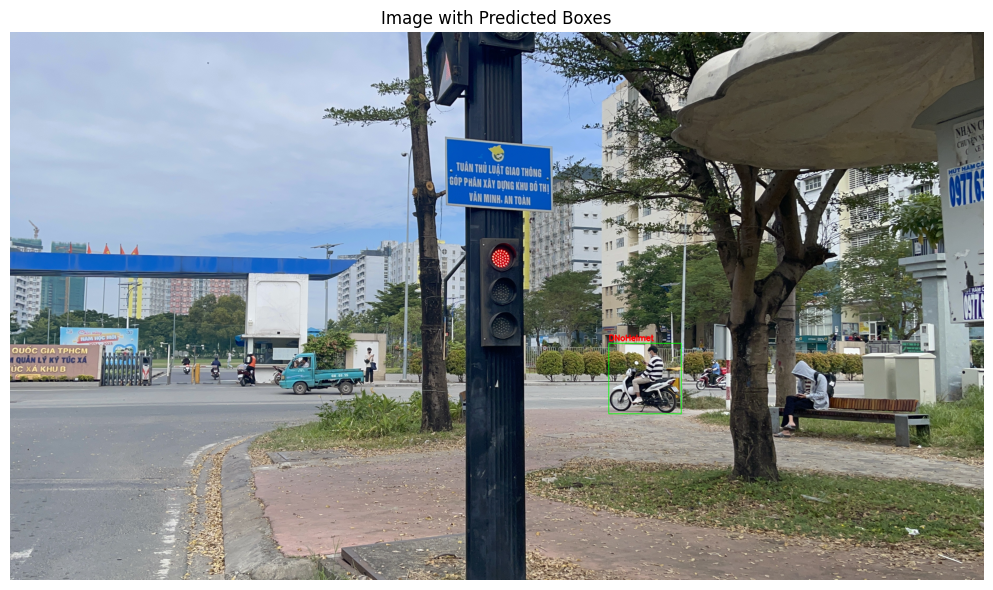

In [18]:
img_PIL = Image.open(image_path)
image_cv = img_PIL.convert("RGB")
image_cv = np.array(image_cv)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    label_text = label_mapping_2[label]
    cv2.rectangle(resized_image,
                  (int(xmin), int(ymin)),
                  (int(xmax), int(ymax)),
                  (0, 255, 0), 2)

    cv2.putText(resized_image, label_text,
                (int(xmin), int(ymin) - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255, 0, 0), 2)

resized_back_image = cv2.resize(resized_image, (original_width, original_height))

# Điều chỉnh bounding boxes về kích thước ban đầu
adjusted_image = image_cv.copy()
for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box

    xmin_orig = int(xmin * scale_x)
    ymin_orig = int(ymin * scale_y)
    xmax_orig = int(xmax * scale_x)
    ymax_orig = int(ymax * scale_y)
    label_text = label_mapping_2[label]
    cv2.rectangle(adjusted_image,
                  (xmin_orig, ymin_orig),
                  (xmax_orig, ymax_orig),
                  (0, 255, 0), 2)

    cv2.putText(adjusted_image, label_text,
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, (255, 0, 0), 4)

plt.figure(figsize = (12,6))

plt.imshow(adjusted_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.tight_layout()
plt.show()